# CNN Pipeline: Multi-Class Defect Classification

In [13]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import pickle
import torch
import torch.nn as nn
import torchvision.models as models
from torch.utils.data import Dataset, DataLoader
from sklearn.metrics import confusion_matrix, accuracy_score
import seaborn as sns
from tqdm.notebook import tqdm
import sys
import cv2

# Patch for pandas 2.0+
import pandas.core.indexes
sys.modules['pandas.indexes'] = pandas.core.indexes
try:
    import pandas.core.indexes.base
    sys.modules['pandas.indexes.base'] = pandas.core.indexes.base
except ImportError: pass

## 1. Load Data & Prepare Dataset

In [14]:
print("Loading LSWMD.pkl...")
with open('LSWMD.pkl', 'rb') as f:
    df = pickle.load(f, encoding='latin1')

def extract_val(x):
    if type(x) == list or type(x).__name__ == 'ndarray':
        if len(x) > 0:
            if type(x[0]) == list or type(x[0]).__name__ == 'ndarray':
                if len(x[0]) > 0: return x[0][0]
                return None
            return x[0]
        return None
    return x

df['failureType'] = df['failureType'].apply(extract_val)
df['trianTestLabel'] = df['trianTestLabel'].apply(extract_val)

df = df.dropna(subset=['failureType'])
df = df[df['failureType'] != 'none']
# (Filtered out 'none' to only classify the 8 defect types)
labels = df['failureType'].unique().tolist()
label_to_idx = {l: i for i, l in enumerate(labels)}
idx_to_label = {i: l for i, l in enumerate(labels)}
print("Classes:", label_to_idx)

Loading LSWMD.pkl...


/var/folders/m_/4r8l9_rn6jng5pdc6lth0yhr0000gn/T/ipykernel_4793/3362326978.py:3: VisibleDeprecationWarning: dtype(): align should be passed as Python or NumPy boolean but got `align=0`. Did you mean to pass a tuple to create a subarray type? (Deprecated NumPy 2.4)
  df = pickle.load(f, encoding='latin1')


Classes: {np.str_('Loc'): 0, np.str_('Edge-Loc'): 1, np.str_('Center'): 2, np.str_('Edge-Ring'): 3, np.str_('Scratch'): 4, np.str_('Random'): 5, np.str_('Near-full'): 6, np.str_('Donut'): 7}


In [15]:
class WaferMultiClassDataset(Dataset):
    def __init__(self, df, img_size=(64, 64)):
        self.df = df.reset_index(drop=True)
        self.img_size = img_size
        
    def __len__(self):
        return len(self.df)
    
    def __getitem__(self, idx):
        wafer = self.df.loc[idx, 'waferMap']
        wafer_resized = cv2.resize(wafer, self.img_size, interpolation=cv2.INTER_NEAREST)
        
        rgb = np.zeros((self.img_size[0], self.img_size[1], 3), dtype=np.float32)
        rgb[:, :, 0][wafer_resized == 1] = 1.0  
        rgb[:, :, 1][wafer_resized == 2] = 1.0  
        
        img_tensor = torch.tensor(rgb).permute(2, 0, 1)
        label_str = self.df.loc[idx, 'failureType']
        return img_tensor, label_to_idx[label_str]

from sklearn.model_selection import train_test_split
# Stratified 95/5 split: each class contributes 95% to train and 5% to test
train_df, test_df = train_test_split(df, test_size=0.1, stratify=df['failureType'], random_state=42)
train_df = train_df.reset_index(drop=True)
test_df = test_df.reset_index(drop=True)

train_ds = WaferMultiClassDataset(train_df, img_size=(64, 64))
test_ds = WaferMultiClassDataset(test_df, img_size=(64, 64))

train_loader = DataLoader(train_ds, batch_size=32, shuffle=True)
test_loader = DataLoader(test_ds, batch_size=32, shuffle=False)
print(f"Total: {len(df)} | Train: {len(train_ds)} (90%) | Test: {len(test_ds)} (10%)")
print("\nPer-class split (stratified):")
print(f"{'Class':<15} {'Total':>8} {'Train (90%)':>12} {'Test (10%)':>10}")
print("-" * 47)
for cls in sorted(df['failureType'].unique()):
    total = (df['failureType'] == cls).sum()
    tr = (train_df['failureType'] == cls).sum()
    te = (test_df['failureType'] == cls).sum()
    print(f"{str(cls):<15} {total:>8} {tr:>12} {te:>10}")

Total: 25519 | Train: 22967 (90%) | Test: 2552 (10%)

Per-class split (stratified):
Class              Total  Train (90%) Test (10%)
-----------------------------------------------
Center              4294         3865        429
Donut                555          499         56
Edge-Loc            5189         4670        519
Edge-Ring           9680         8712        968
Loc                 3593         3234        359
Near-full            149          134         15
Random               866          779         87
Scratch             1193         1074        119


## 2. Define CNN Architecture

In [16]:
device = torch.device('cuda' if torch.cuda.is_available() else 'mps' if torch.backends.mps.is_available() else 'cpu')

# Load ResNet18 and adapt for 9 classes
model = models.resnet18(weights=models.ResNet18_Weights.IMAGENET1K_V1)
num_ftrs = model.fc.in_features
model.fc = nn.Linear(num_ftrs, len(labels))
model = model.to(device)

criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.AdamW(model.parameters(), lr=1e-3)

## 3. Training Setup

In [17]:
num_epochs = 20
print("Starting Training...")

for epoch in range(num_epochs):
    model.train()
    epoch_loss = 0
    correct = 0
    total = 0
    for imgs, tgts in tqdm(train_loader, desc=f"Epoch {epoch+1}"):
        imgs, tgts = imgs.to(device), tgts.to(device)
        
        optimizer.zero_grad()
        outputs = model(imgs)
        loss = criterion(outputs, tgts)
        loss.backward()
        optimizer.step()
        
        epoch_loss += loss.item()
        _, predicted = outputs.max(1)
        total += tgts.size(0)
        correct += predicted.eq(tgts).sum().item()
        
    print(f"Epoch {epoch+1} | Loss: {epoch_loss/len(train_loader):.4f} | Acc: {100.*correct/total:.2f}%")

Starting Training...


Epoch 1:   0%|          | 0/718 [00:00<?, ?it/s]

Epoch 1 | Loss: 0.4250 | Acc: 84.82%


Epoch 2:   0%|          | 0/718 [00:00<?, ?it/s]

Epoch 2 | Loss: 0.2564 | Acc: 90.90%


...

Epoch 18 | Loss: 0.0284 | Acc: 99.09%


Epoch 19:   0%|          | 0/718 [00:00<?, ?it/s]

Epoch 19 | Loss: 0.0286 | Acc: 99.14%


Epoch 20:   0%|          | 0/718 [00:00<?, ?it/s]

Epoch 20 | Loss: 0.0241 | Acc: 99.27%


## 4. Evaluation

Testing...


  0%|          | 0/80 [00:00<?, ?it/s]

Test Accuracy: 0.9278996865203761


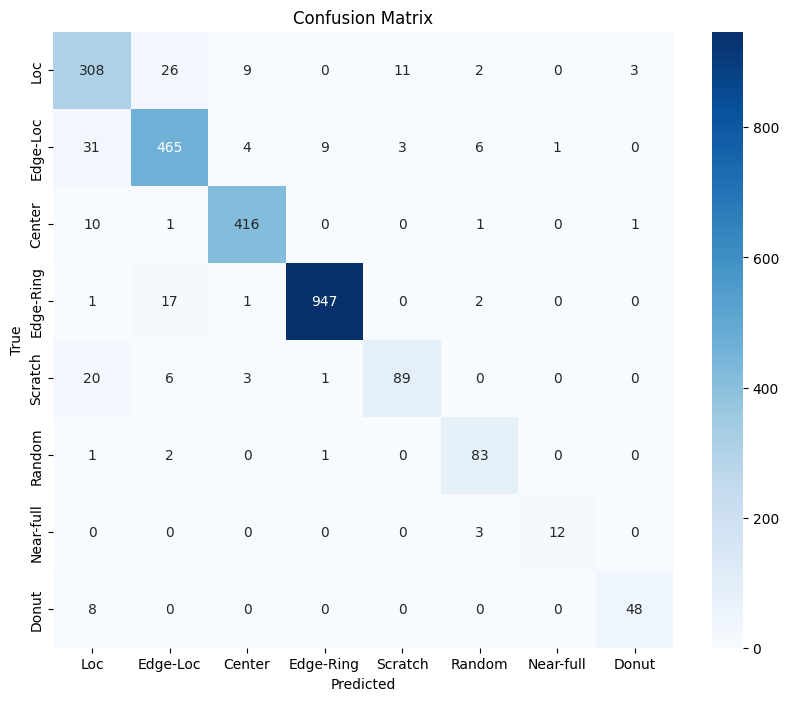

In [19]:
print("Testing...")
model.eval()
all_preds = []
all_tgts = []

with torch.no_grad():
    for imgs, tgts in tqdm(test_loader):
        imgs = imgs.to(device)
        outputs = model(imgs)
        _, preds = outputs.max(1)
        all_preds.extend(preds.cpu().numpy())
        all_tgts.extend(tgts.numpy())
        
print("Test Accuracy:", accuracy_score(all_tgts, all_preds))

# Confusion Matrix
cm = confusion_matrix(all_tgts, all_preds)
plt.figure(figsize=(10,8))
sns.heatmap(cm, annot=True, fmt='d', xticklabels=labels, yticklabels=labels, cmap='Blues')
plt.ylabel('True')
plt.xlabel('Predicted')
plt.title('Confusion Matrix')
plt.show()